# 8. AIND Ephys Processing QC

Build an `AINDEPhysProcessingQCScanConfig`, expand it with `GridScanGenerationTask`, and run the `AINDEPhysProcessingQCTask` for each coordinate. The task itself clones [aind-ephys-processing-qc](https://github.com/AllenNeuralDynamics/aind-ephys-processing-qc) on first use, patches `qc_utils.py` for spikeinterface API drift (`bandpass_filter` cutoff guard, `template_metrics['half_width']` → `'trough_half_width'`), seeds its `data/` with the results-collector layout + dispatch `job_*.json` + a synthetic `ecephys_*` session folder, runs `code/run_capsule.py`, and copies the per-recording figures + `quality_control_<name>.json` into `coordinate_output_root` (`obi-output/08_aind_ephys_processing_qc/grid_scan/0/`).

## Imports and prerequisites

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import obi_one as obi

In [2]:
subprocess.run(
    [
        "uv", "pip", "install", "--python", sys.executable,
        "aind-data-schema", "aind-qcportal-schema", "matplotlib",
    ],
    check=True,
)

Using Python 3.12.9 environment at: /Users/james/Documents/obi/code/obi-main/obi-one/.venv


Resolved 26 packages in 264ms
Uninstalled 2 packages in 8ms
Installed 2 packages in 2ms
 - pydantic==2.12.5
 + pydantic==2.11.10
 - pydantic-core==2.41.5
 + pydantic-core==2.33.2


CompletedProcess(args=['uv', 'pip', 'install', '--python', '/Users/james/Documents/obi/code/obi-main/obi-one/.venv/bin/python', 'aind-data-schema', 'aind-qcportal-schema', 'matplotlib'], returncode=0)

## Build the scan config

In [3]:
collected_output_path = (
    Path.cwd() / "../../../obi-output/07_aind_ephys_results_collector/grid_scan/0"
).resolve()
dispatch_output_path = (
    Path.cwd() / "../../../obi-output/01_aind_ephys_dispatch/grid_scan/0"
).resolve()
for p in (collected_output_path, dispatch_output_path):
    assert p.exists(), f"{p} not found. Run earlier notebooks first."

scan_config = obi.AINDEPhysProcessingQCScanConfig(
    initialize=obi.AINDEPhysProcessingQCScanConfig.Initialize(
        collected_output_path=collected_output_path,
        dispatch_output_path=dispatch_output_path,
        compute_event_metrics=False,
        min_duration_allow_failed=0.0,
    ),
)

## Generate the grid scan and run the QC task

In [4]:
grid_scan = obi.GridScanGenerationTask(
    form=scan_config,
    output_root="../../../obi-output/08_aind_ephys_processing_qc/grid_scan",
    coordinate_directory_option="ZERO_INDEX",
)
grid_scan.execute()

obi.run_tasks_for_generated_scan(grid_scan)

[2026-04-29 18:15:27,356] INFO: Seeded data dir: /tmp/aind-ephys-processing-qc/data


[2026-04-29 18:15:27,356] INFO: Running python -u run_capsule.py --min-duration-allow-failed 0.0 --no-event-metrics


[2026-04-29 18:15:32,944] INFO: Running Ephys QC with the following parameters:
	COMPUTE EVENT METRICS: True
	MIN DURATION ALLOW FAILED: 0.0
Found 1 JSON job files
Events from HARP not found. Trigger event metrics will not be generated.
Recording block0_None_recording1
Failed to load bad channel labels for block0_None_recording1
Generating RAW DATA metrics
Generating PSD metrics
Generating NOISE metrics
Generating SATURATION metric
	Saturation threshold for block0_None_recording1 not available. Cannot generate saturation metrics.
	Motion not found for block0_None_recording1
Generating UNIT YIELD metric
Smooting amplitudes failed.
Smooting firing rates failed.
Generating FIRING RATE metric
EPHYS QC time: 3.88s



[PosixPath('../../../obi-output/08_aind_ephys_processing_qc/grid_scan/0')]

## Inspect the QualityControl document and figures

coordinate_output_root: ../../../obi-output/08_aind_ephys_processing_qc/grid_scan/0
==== quality_control_block0_None_recording1.json ====
  schema_version: 2.4.1
  Total metrics: 5
      Raw data  Raw data block0_None_recording1
      Raw data  PSD block0_None_recording1
      Raw data  RMS block0_None_recording1
    Processing  Unit Metrics Yield - block0_None_recording1
    Processing  Firing rate - block0_None_recording1

Generated 5 figure(s):
  quality_control_block0_None_recording1/firing_rate.png


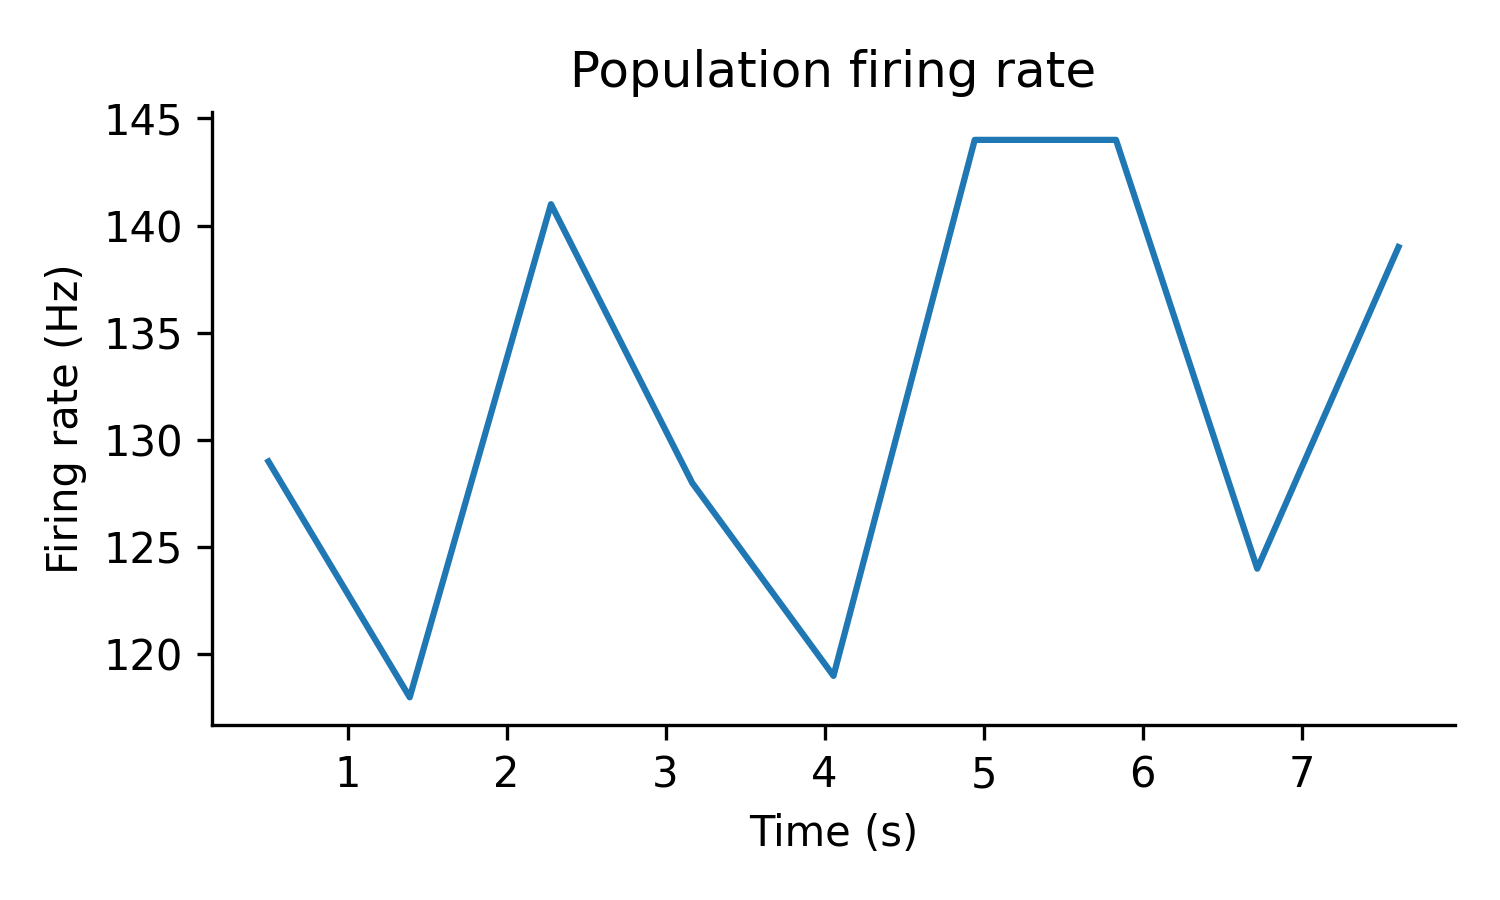

  quality_control_block0_None_recording1/psd.png


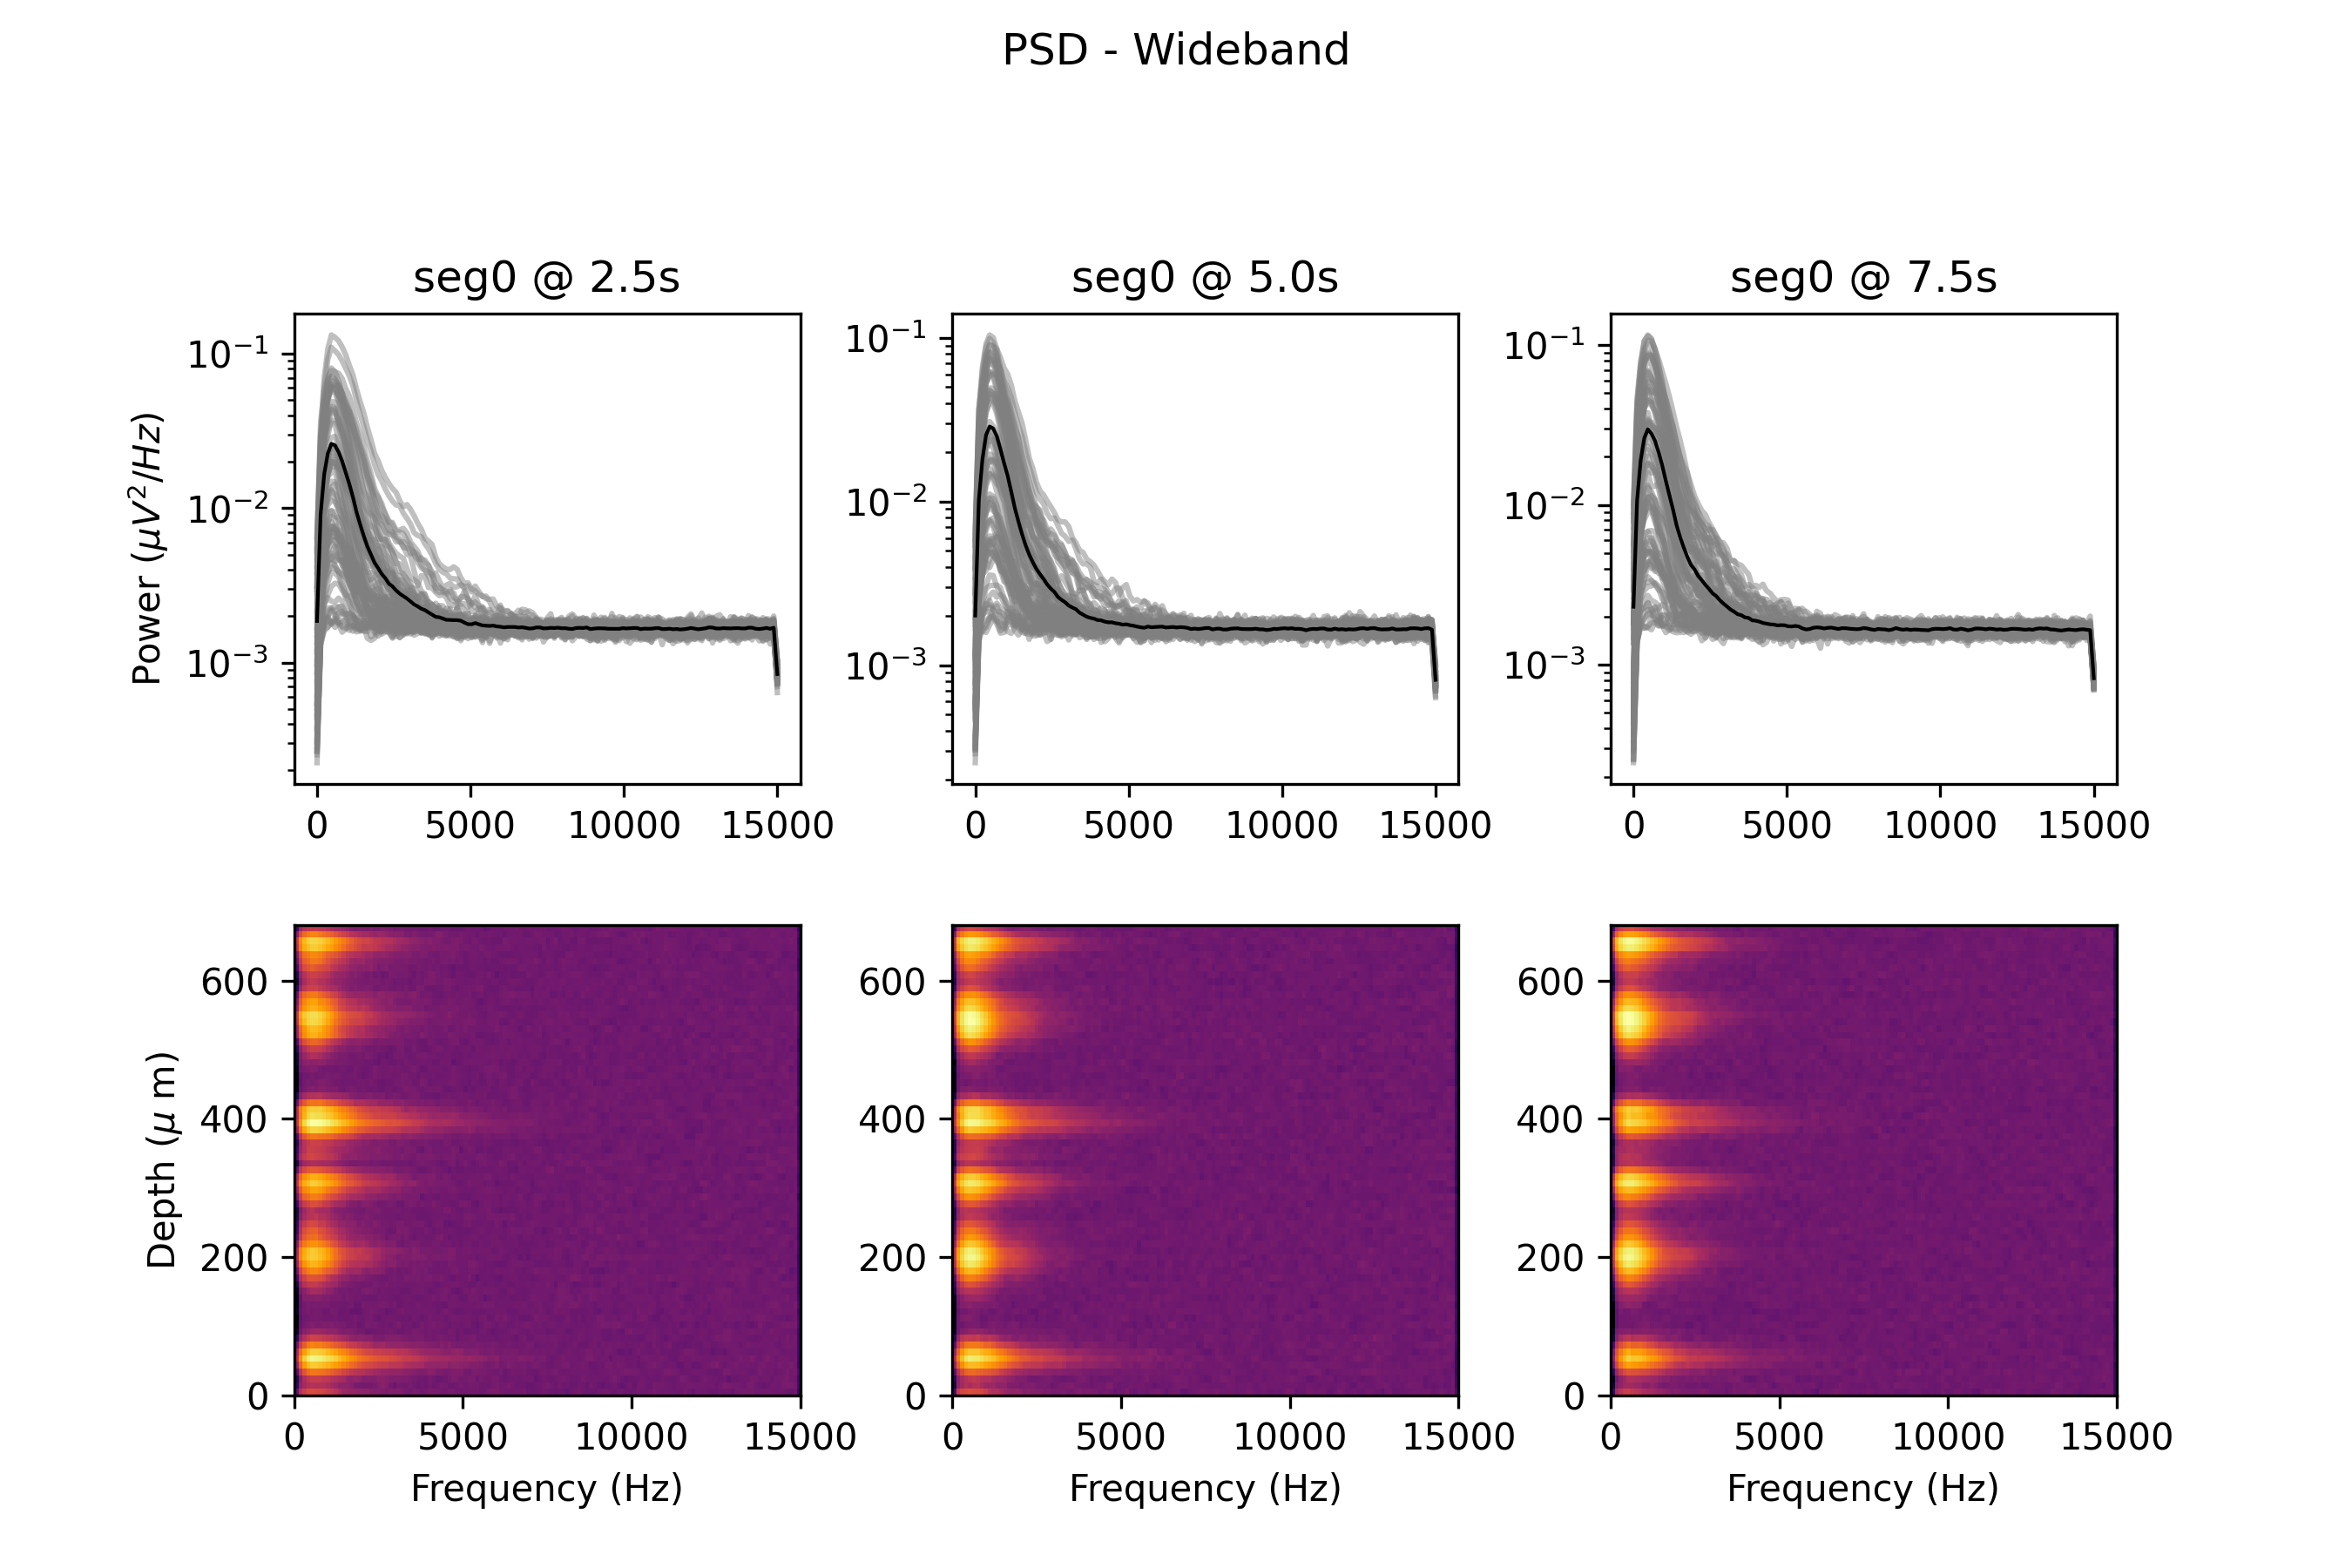

  quality_control_block0_None_recording1/rms.png


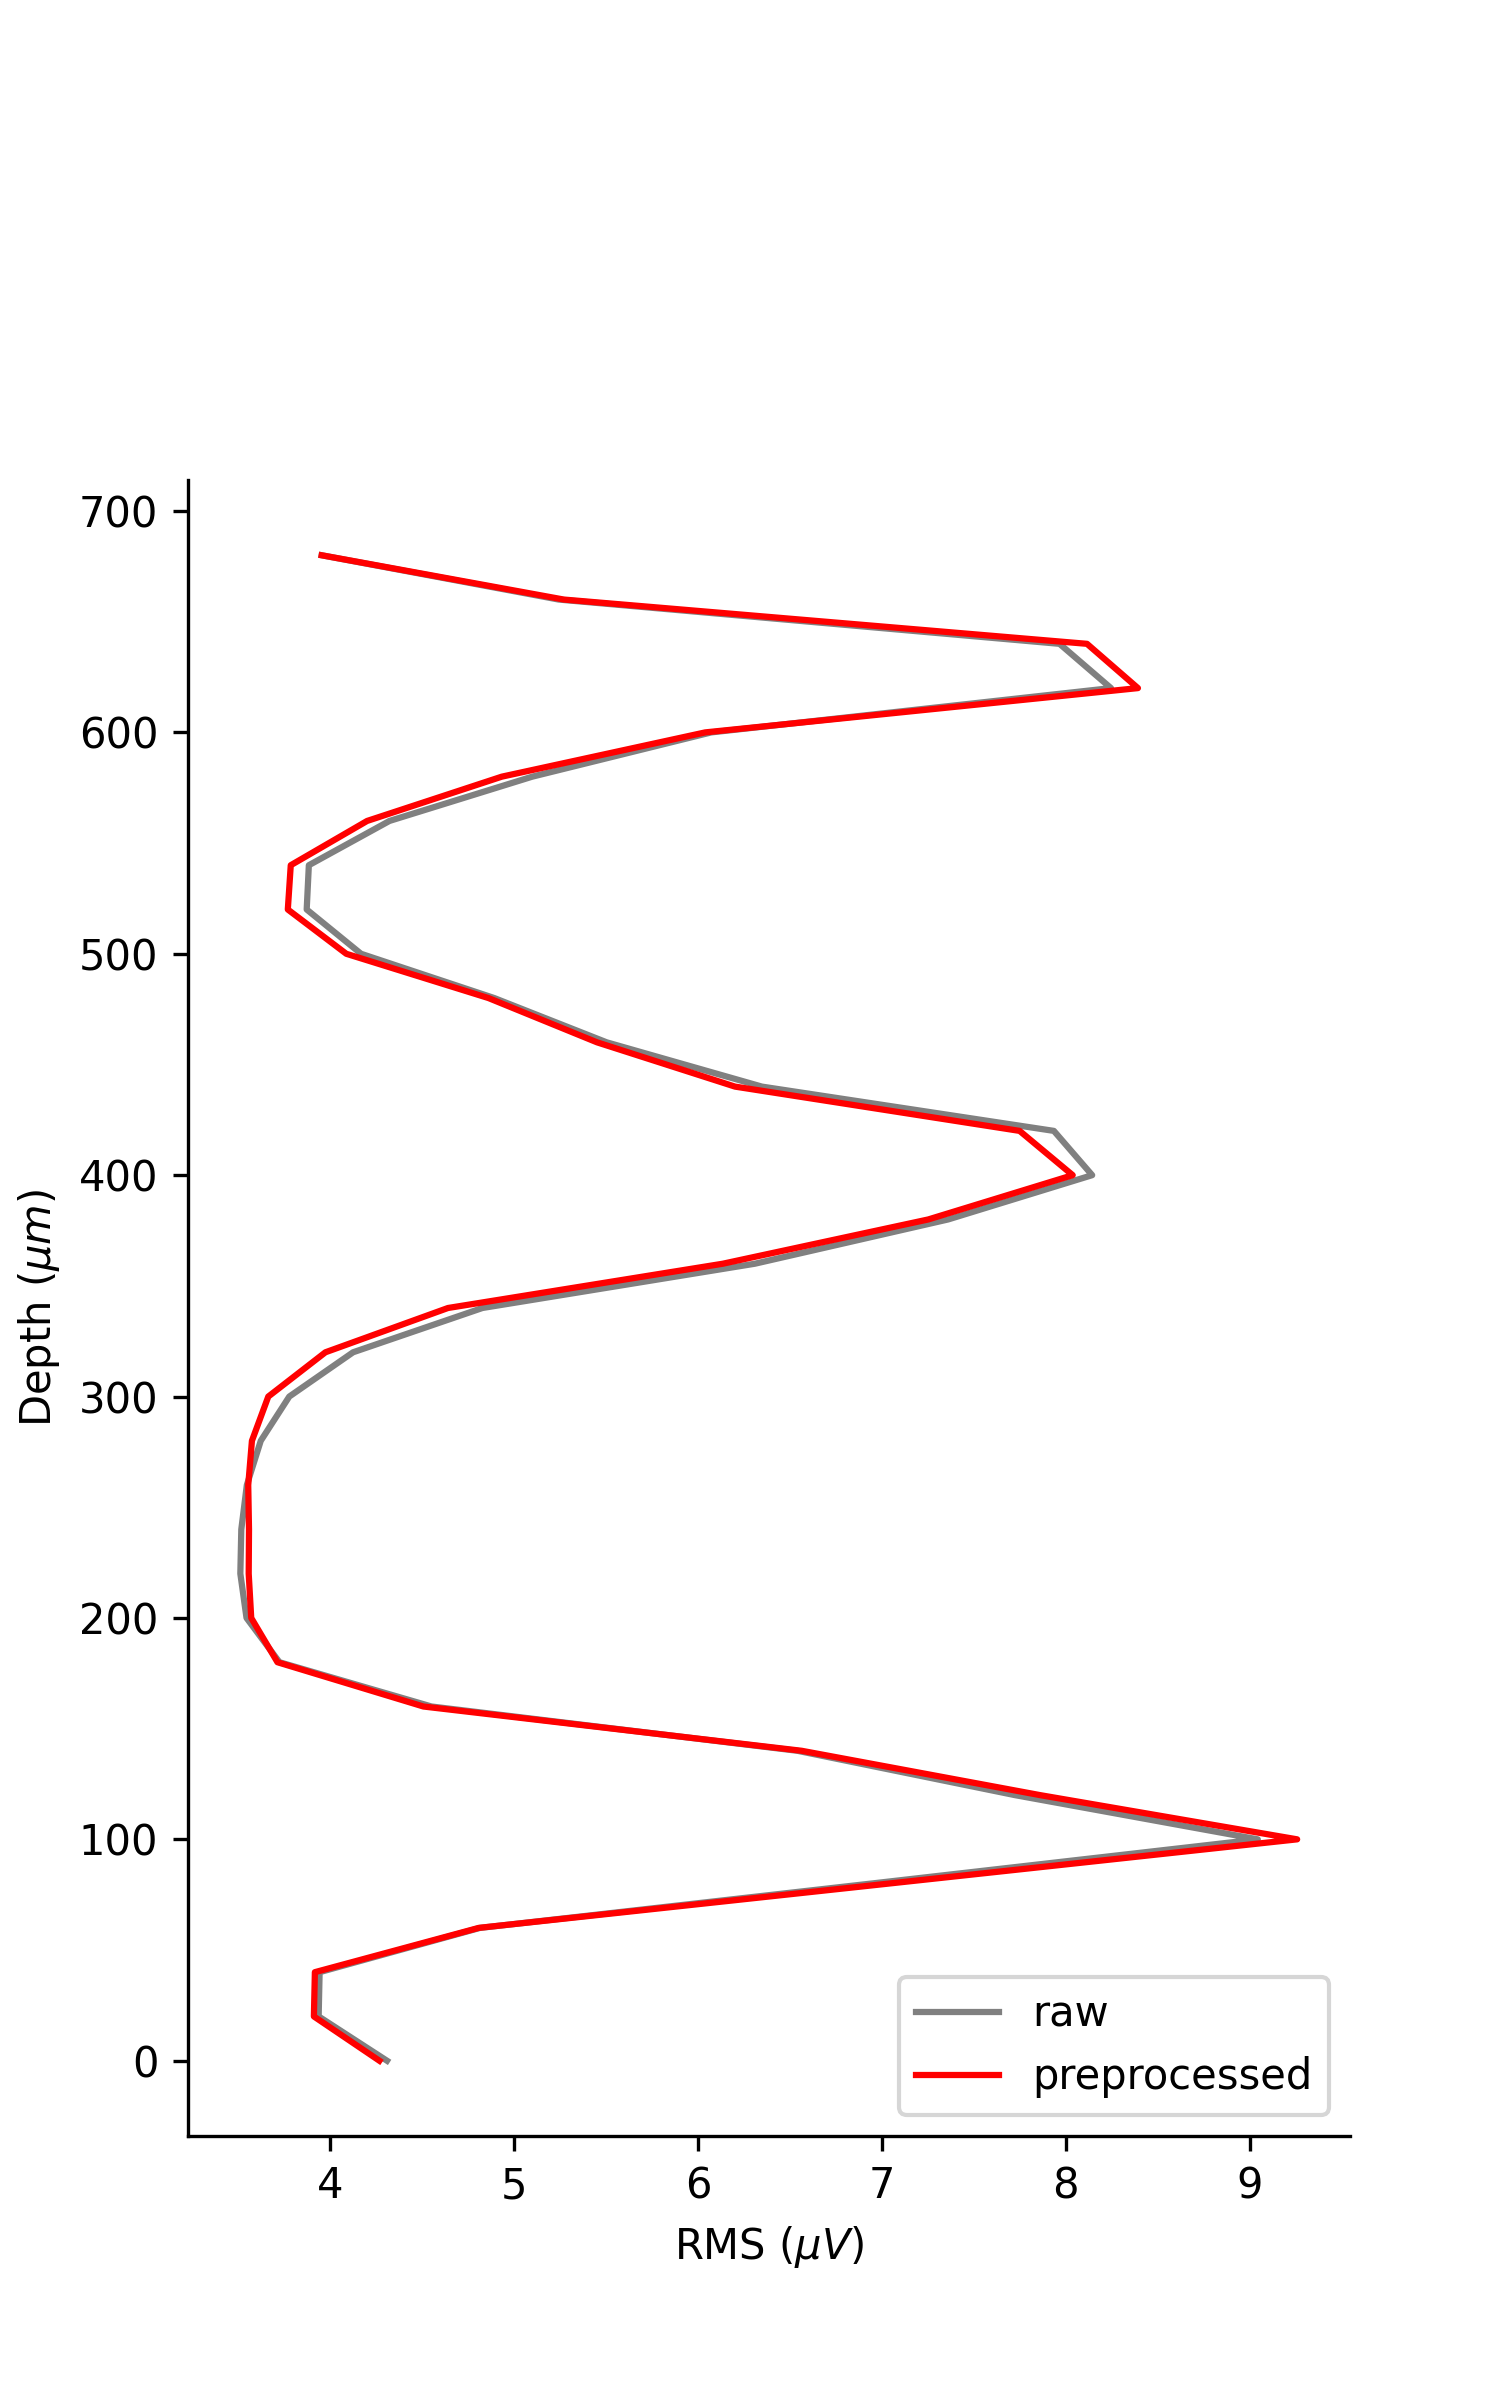

  quality_control_block0_None_recording1/traces_raw.png


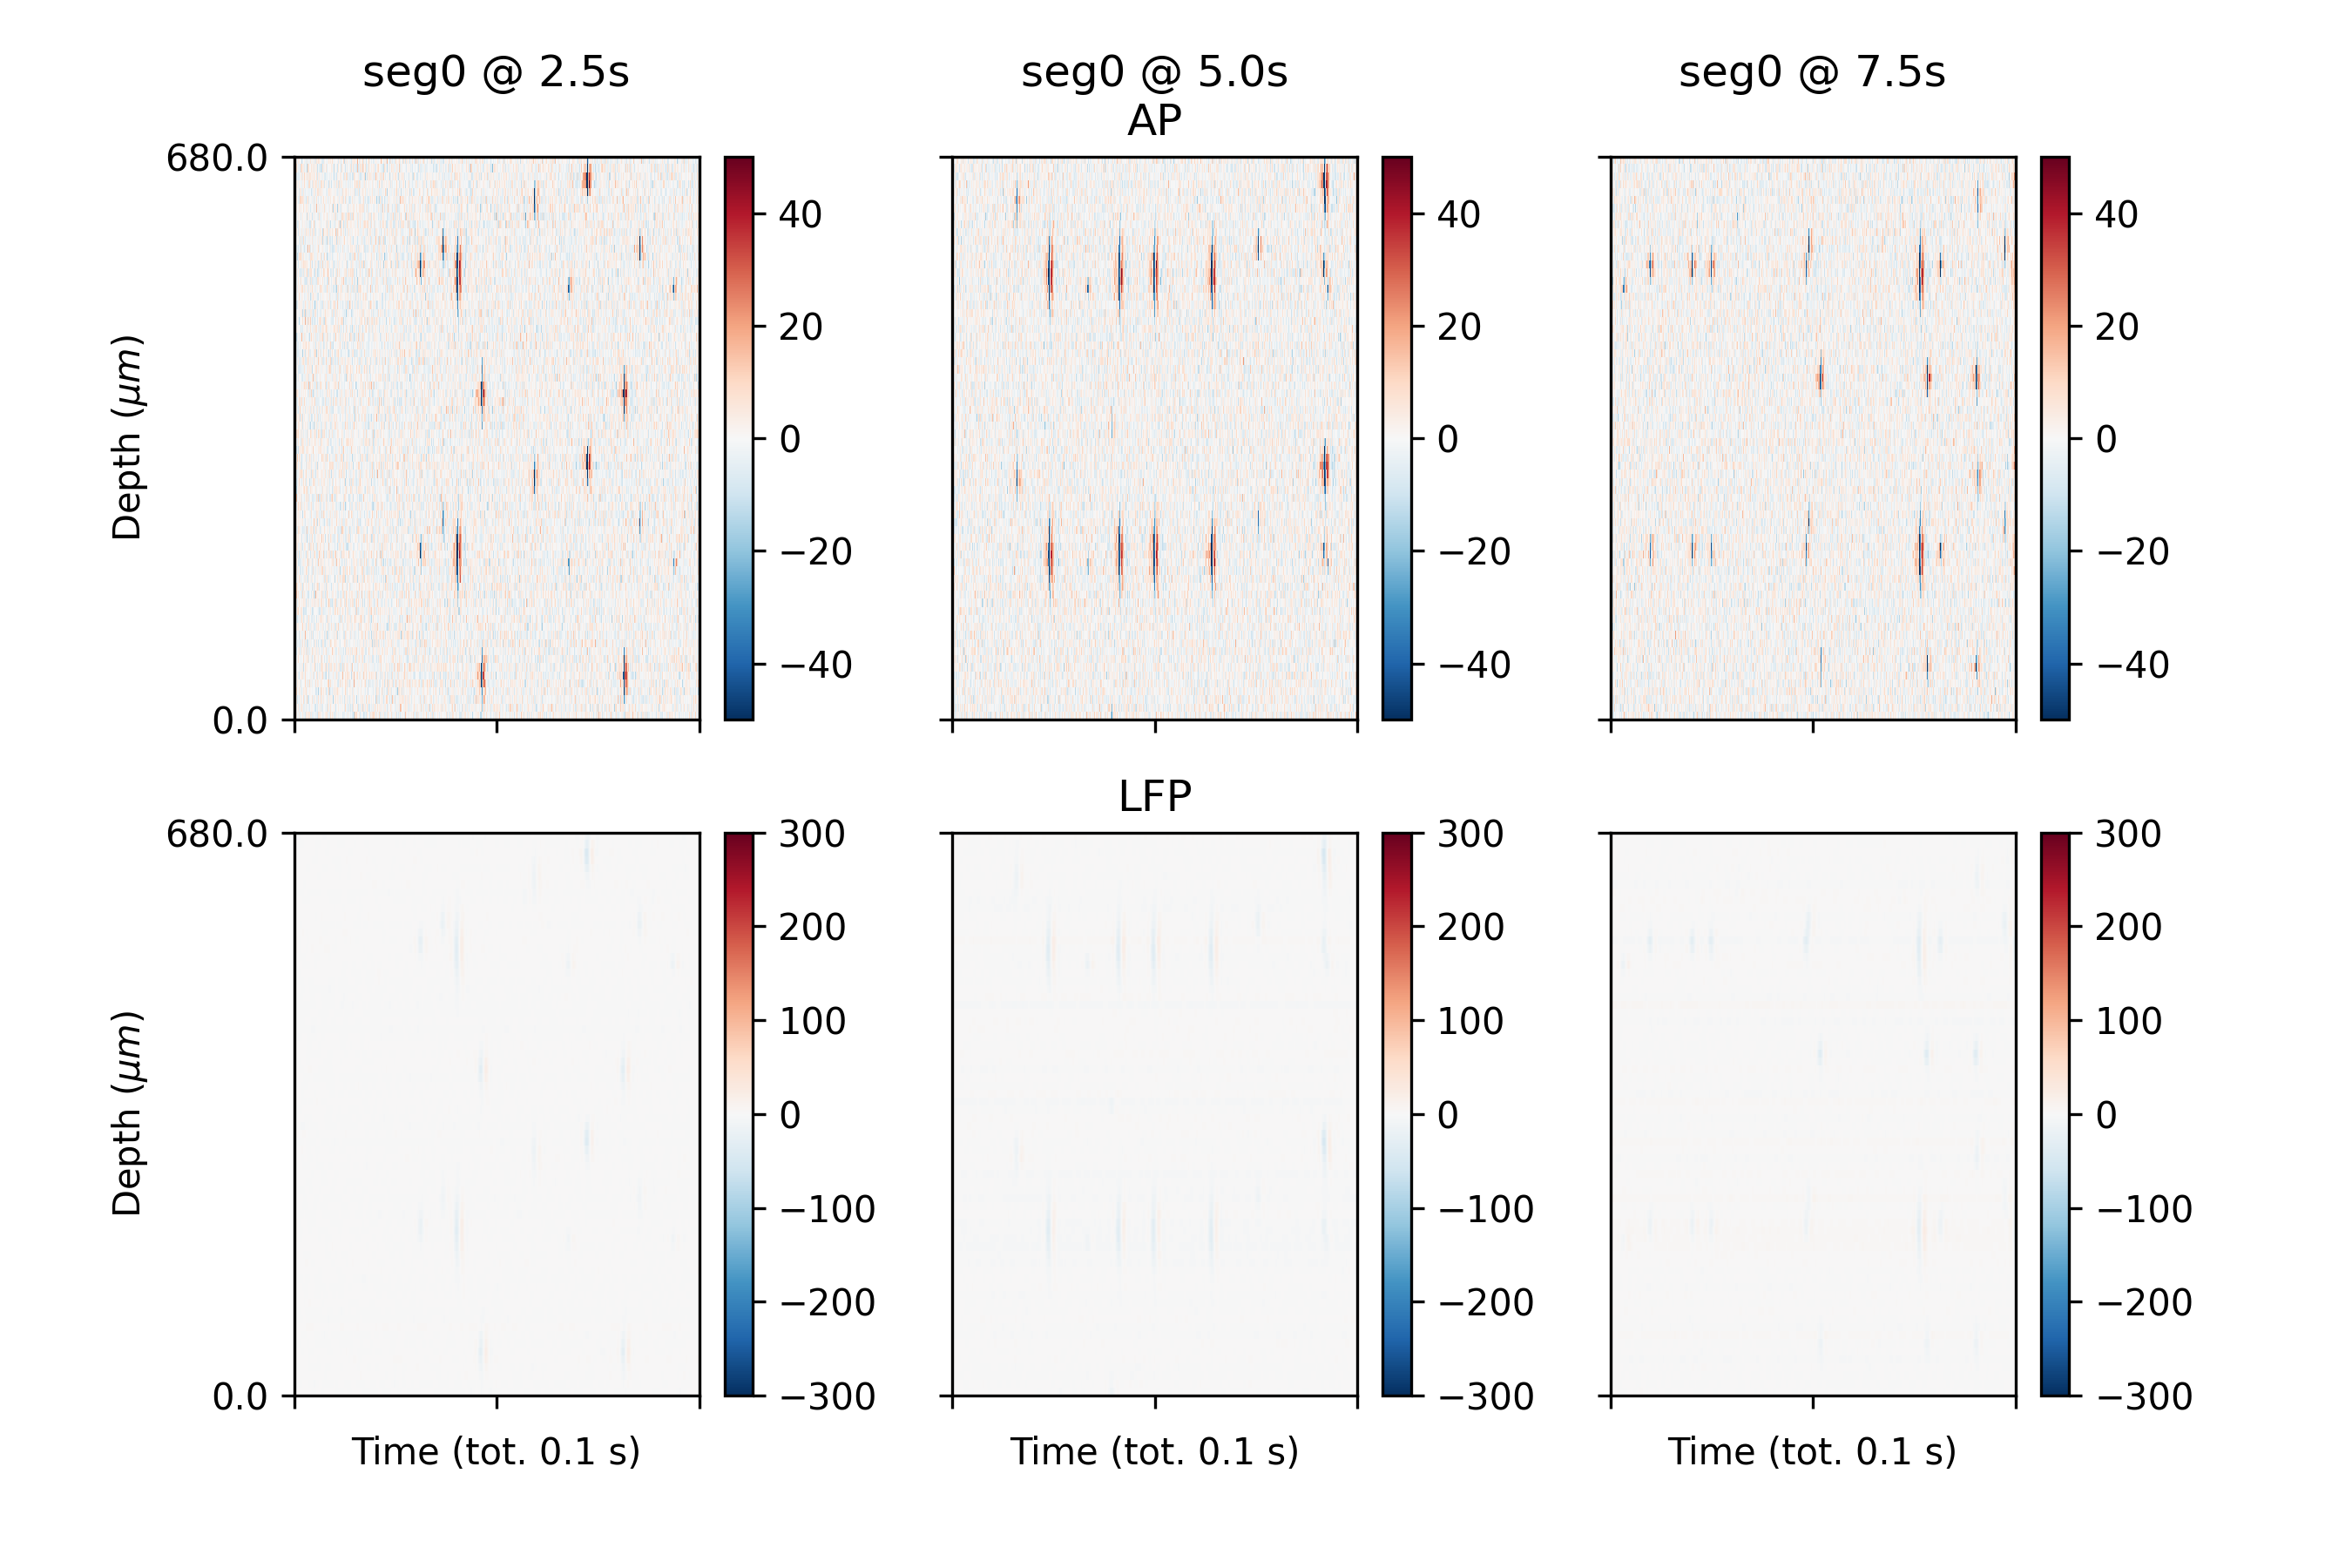

  quality_control_block0_None_recording1/unit_yield.png


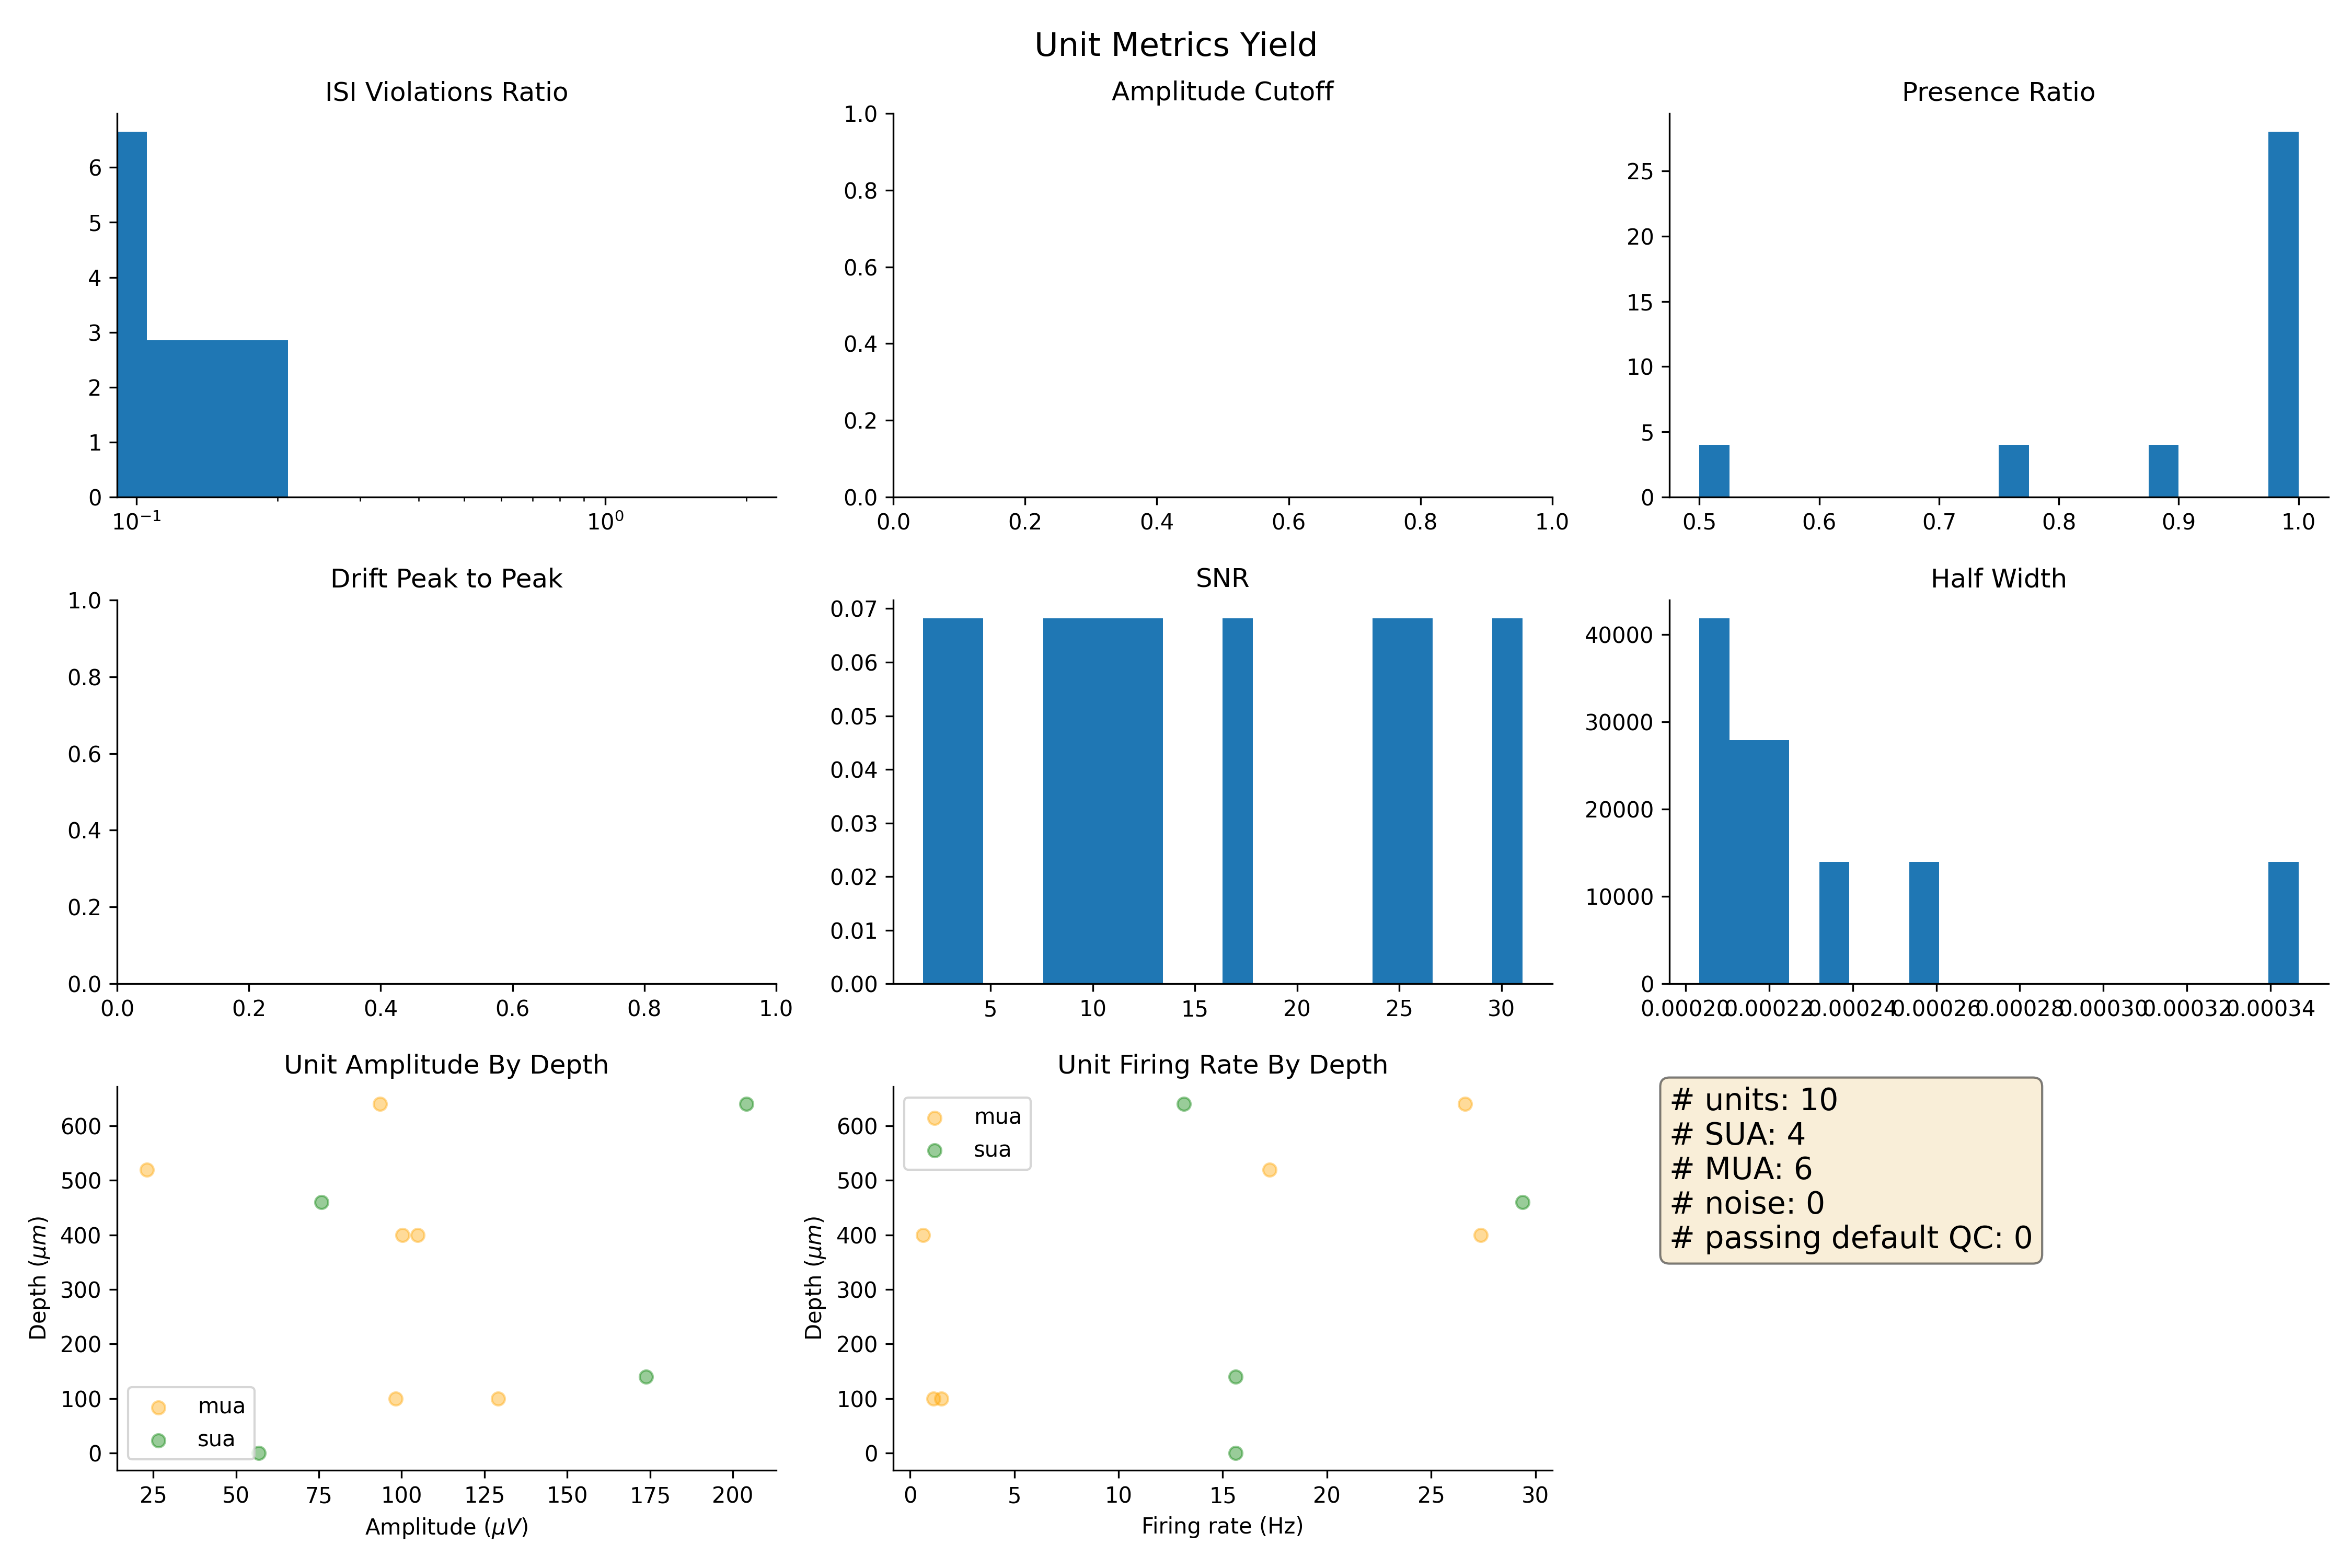

In [5]:
from IPython.display import Image, display

coord_dir = Path(grid_scan.single_configs[0].coordinate_output_root)
print("coordinate_output_root:", coord_dir)

qc_files = sorted(coord_dir.glob("quality_control_*.json"))
for qc_path in qc_files:
    print(f"==== {qc_path.name} ====")
    qc = json.loads(qc_path.read_text())
    print("  schema_version:", qc.get("schema_version"))
    metrics = qc.get("metrics", [])
    print(f"  Total metrics: {len(metrics)}")
    for m in metrics:
        print(f"    {m.get('stage'):>10}  {m.get('name')}")
    print()

pngs = sorted(coord_dir.rglob("*.png"))
print(f"Generated {len(pngs)} figure(s):")
for p in pngs:
    print(" ", p.relative_to(coord_dir))
    display(Image(filename=str(p)))